In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Define the basin states

bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

In [ ]:
v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000

x0 = 1.0
k = 0.1
Vc = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
eps = 0.05


SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=Vc[0] * eps)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)


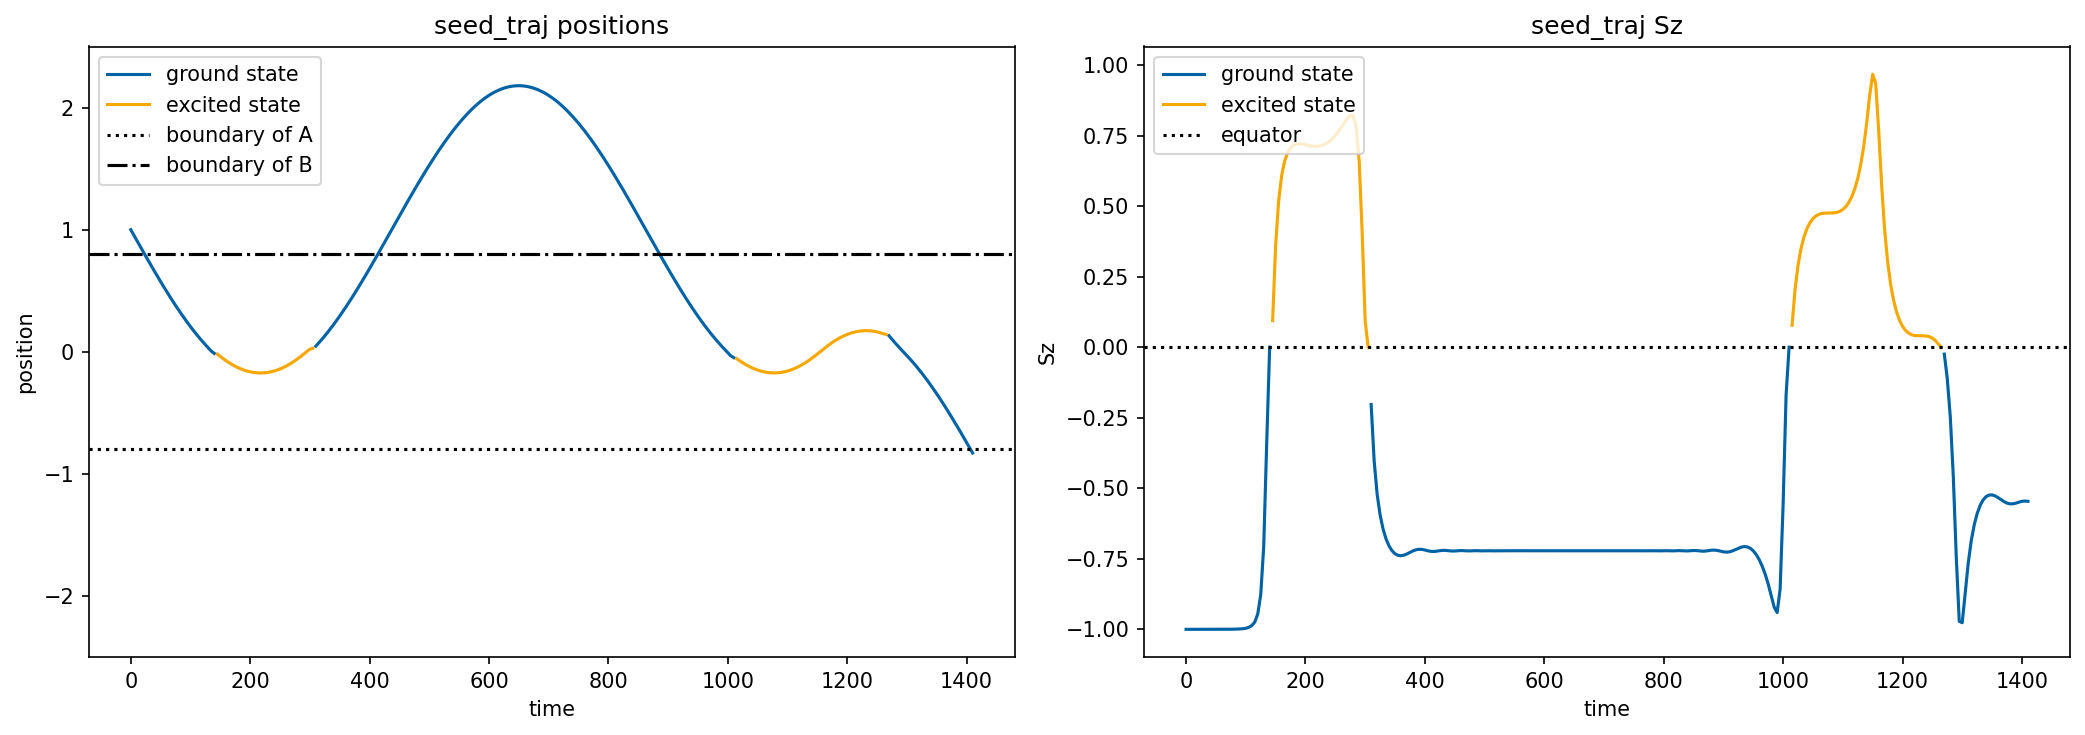

In [10]:
# PLOT SEED TRAJECTORY

labelstates = ["ground state", "excited state"]
colorstates = ["#0063A6","#F6A800","#666666"]

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

# --- Create subplots ---
fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

# Left: Positions
axes[0].plot(np.arange(len(seed_traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
axes[0].plot(np.arange(len(seed_traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
axes[0].set_xlabel("time")
axes[0].set_ylabel("position")
axes[0].set_ylim([-2.5, 2.5])
axes[0].set_title("seed_traj positions")
axes[0].legend(loc=2)

# Right: Sz
axes[1].plot(np.arange(len(seed_traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
axes[1].plot(np.arange(len(seed_traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
axes[1].set_xlabel("time")
axes[1].set_ylabel("Sz")
axes[1].set_title("seed_traj Sz")
axes[1].legend(loc=2)

plt.tight_layout()
plt.show()